In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import warnings
import pandas as pd
import numpy as np
import pickle
import sys; sys.path.insert(0, '..')

from joblib import Parallel, delayed
from src.regression_model import (
    mev_transformation, prepare_training_set, single_regression,
    multivariate_selection, get_combinations, run_fwl_model,
    mask_selection, select_models
)
from src.plot_function import plot_backtest

pd.options.display.float_format = '{:.3f}'.format
warnings.simplefilter(action ='ignore', category = pd.errors.PerformanceWarning)
warnings.filterwarnings('ignore', category = RuntimeWarning)
warnings.filterwarnings('ignore', category = UserWarning)

In [3]:
# Import MEV Data
MEV_RAW_DATA = pd.read_csv(
    '../data/raw/mev_data.csv'
)

# Data preparation
MEV_RAW_DATA = MEV_RAW_DATA.drop(
    ["Year", "Quarter", "Month"],
    axis = 1
)
MEV_RAW_DATA["Date"] = pd.to_datetime(MEV_RAW_DATA["Date"])
MEV_RAW_DATA = MEV_RAW_DATA.set_index("Date")

# Show table
MEV_RAW_DATA.head(5)

,GDP,FDI,HHD,COPD,GOVD,GOVE,IMP,EXP,PIR,MLR,...,CCI,PII,BSI,TOUR,BROLP,INDPRO,CAPU,BROMO,FRES,LAB
Date,,,,,,,,,,,,,,,,,,,,,
1993-03-31,1067301.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,18.750,NaN,NaN,NaN,NaN,NaN
1993-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,18.650,NaN,NaN,NaN,NaN,NaN
1993-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,18.500,NaN,NaN,NaN,NaN,NaN
1993-06-30,1039924.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,17.650,NaN,NaN,NaN,NaN,NaN
1993-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,16.800,NaN,NaN,NaN,NaN,NaN


In [4]:
# Constant parameters
DEP_COL = "odr" #Depending on column label created
MEV_COL = "mev" #Depending on column label created
TYPE_COL = "type" #Depending on column label created
SIGN_COL = "sign" #Depending on column label created
GROUP_COL = "group" #Depending on column label created
MODEL_METHOD = "Logit" #"Logit", "CF" or "CCI"

# Create MEV Expected sign with default rate and MEV Group before transformation
"""
Sign:
    Positive:  (1)  --> MEV(s) increases, PD increases
    Negative:  (-1) --> MEV(s) increases, PD decreases
    Either:    (0)  --> Either way, let model design the trend
Group:
    The original group need to remain before several forms of transformation
"""
SIGN_GROUP = {
    MEV_COL: MEV_RAW_DATA.columns.tolist(),
    TYPE_COL: [
        "Flow", "Flow", "Flow", "Flow", "Flow", "Flow", 
        "Flow", "Flow", "Rate", "Rate", "Index", "Index", 
        "Price", "Rate", "Index", "Index", "Index", "Flow", 
        "Price", "Index", "Index", "Flow", "Flow", "Index"
    ],
    SIGN_COL: [
        -1, -1, 1, -1, 1, 0,
        -1, -1, 0, 1, 1, 1,
        -1, 1, -1, -1, -1, -1,
        1, -1, -1, -1, -1, -1
    ],
    GROUP_COL: MEV_RAW_DATA.columns.tolist()
}

# To DataFrame
MEV_SIGN_GROUP = pd.DataFrame.from_dict(SIGN_GROUP)

# Show table
MEV_SIGN_GROUP.head(5)

,mev,type,sign,group
0,GDP,Flow,-1,GDP
1,FDI,Flow,-1,FDI
2,HHD,Flow,1,HHD
3,COPD,Flow,-1,COPD
4,GOVD,Flow,1,GOVD


In [5]:
# MEV(s) Transformation
X_Data, X_Sign = mev_transformation(
    raw_data = MEV_RAW_DATA,
    sign_group = MEV_SIGN_GROUP,
    mev_col = MEV_COL,
    tpye_col = TYPE_COL
)

=== Processing ===
[MEV(s) Transformation]
=== Result ===
Total MEV(s): 840
[INFO]: Export - '..data/processed/mev_transformed.parquet'


In [6]:
# Import ODR Data
y = pd.read_parquet(
    '../data/processed/monthly_odr.parquet',
    engine = 'pyarrow'
)

# Show table
y.head(5)

,n,bad,odr
AS_OF_DATE,,,
2014-01-31,564,59,0.105
2014-02-28,1118,128,0.114
2014-03-31,1821,183,0.100
2014-04-30,2425,248,0.102
2014-05-31,3020,313,0.104


=== Processing ===
[Data preparation for Logit model]


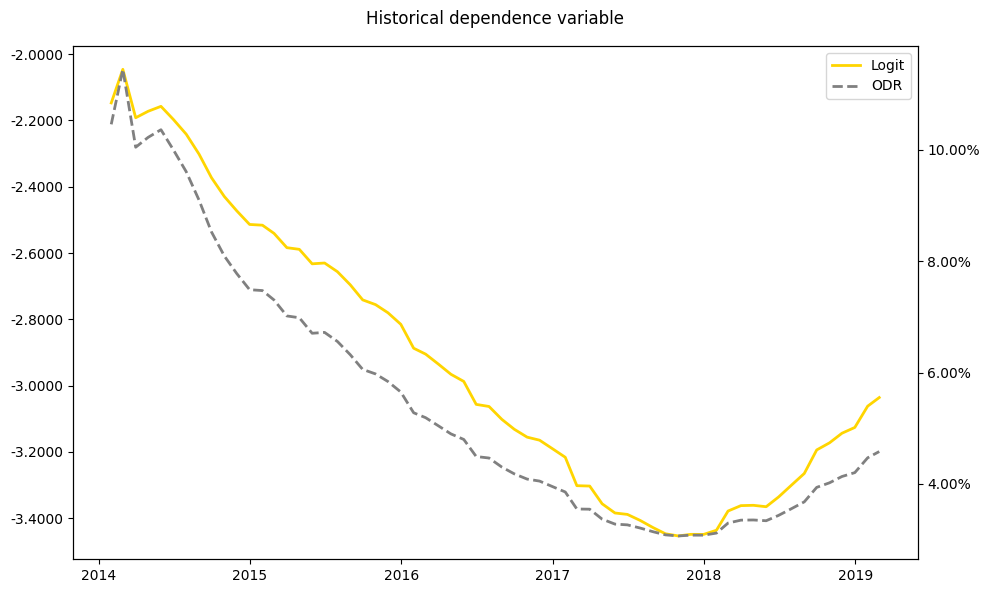

In [7]:
# Training set preparation
X_train, y_train, fig = prepare_training_set(
    X = X_Data,
    y = y,
    dep_col = DEP_COL,
    model_method = MODEL_METHOD,
    outplot = True
)

# Loan standardized parameters for CF Model
if MODEL_METHOD == "CF":
    std_params = pd.read_parquet(
        '../model/standardized_params.parquet',
        engine = 'pyarrow'
    )
    print("[INFO]: Loaded standardized parameters for CF Model")
else:
    std_params = None

=== Processing ===
[Univariate analysis]
=== Result ===
Number of passed variables: 214


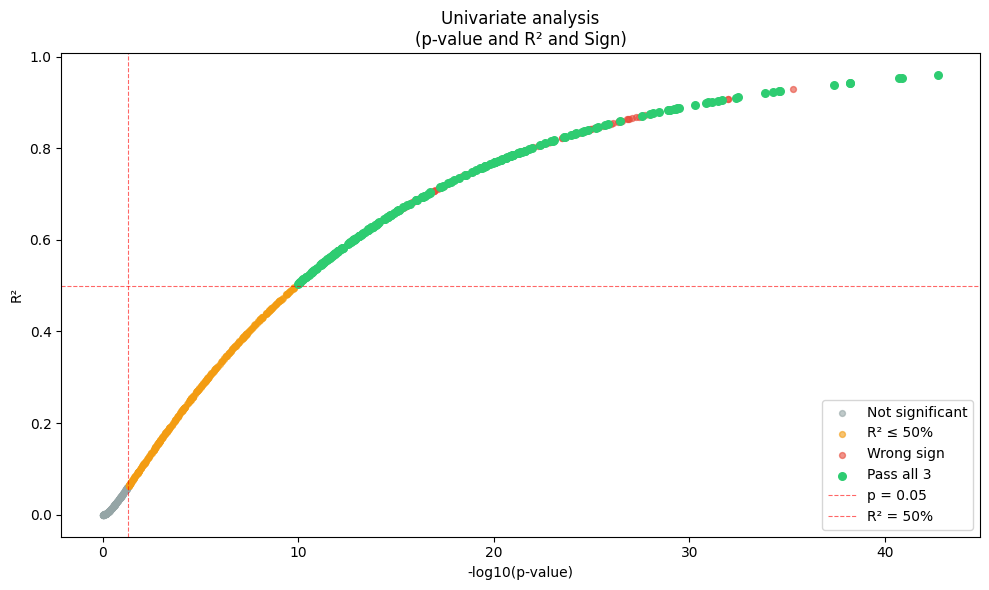

In [8]:
# Univariate analysis
"""
Selection criteria:
    1. p-value significant of 0.05 (p-value < 0.05) and
    2. R-Square is high (R-Sqaure > 50%) and 
    3. Coefficient follows intuitive sign or either sign is allowed
       where p-value and R-Square are passed.

"""
univariate_result, fig = single_regression(
    X = X_train,
    y = y_train,
    sign = X_Sign,
    mev_col = MEV_COL,
    sign_col = SIGN_COL,
    outplot = True
)

=== Processing ===
[Multivariate analysis]
=== Result ===
Number of passed variables: 33


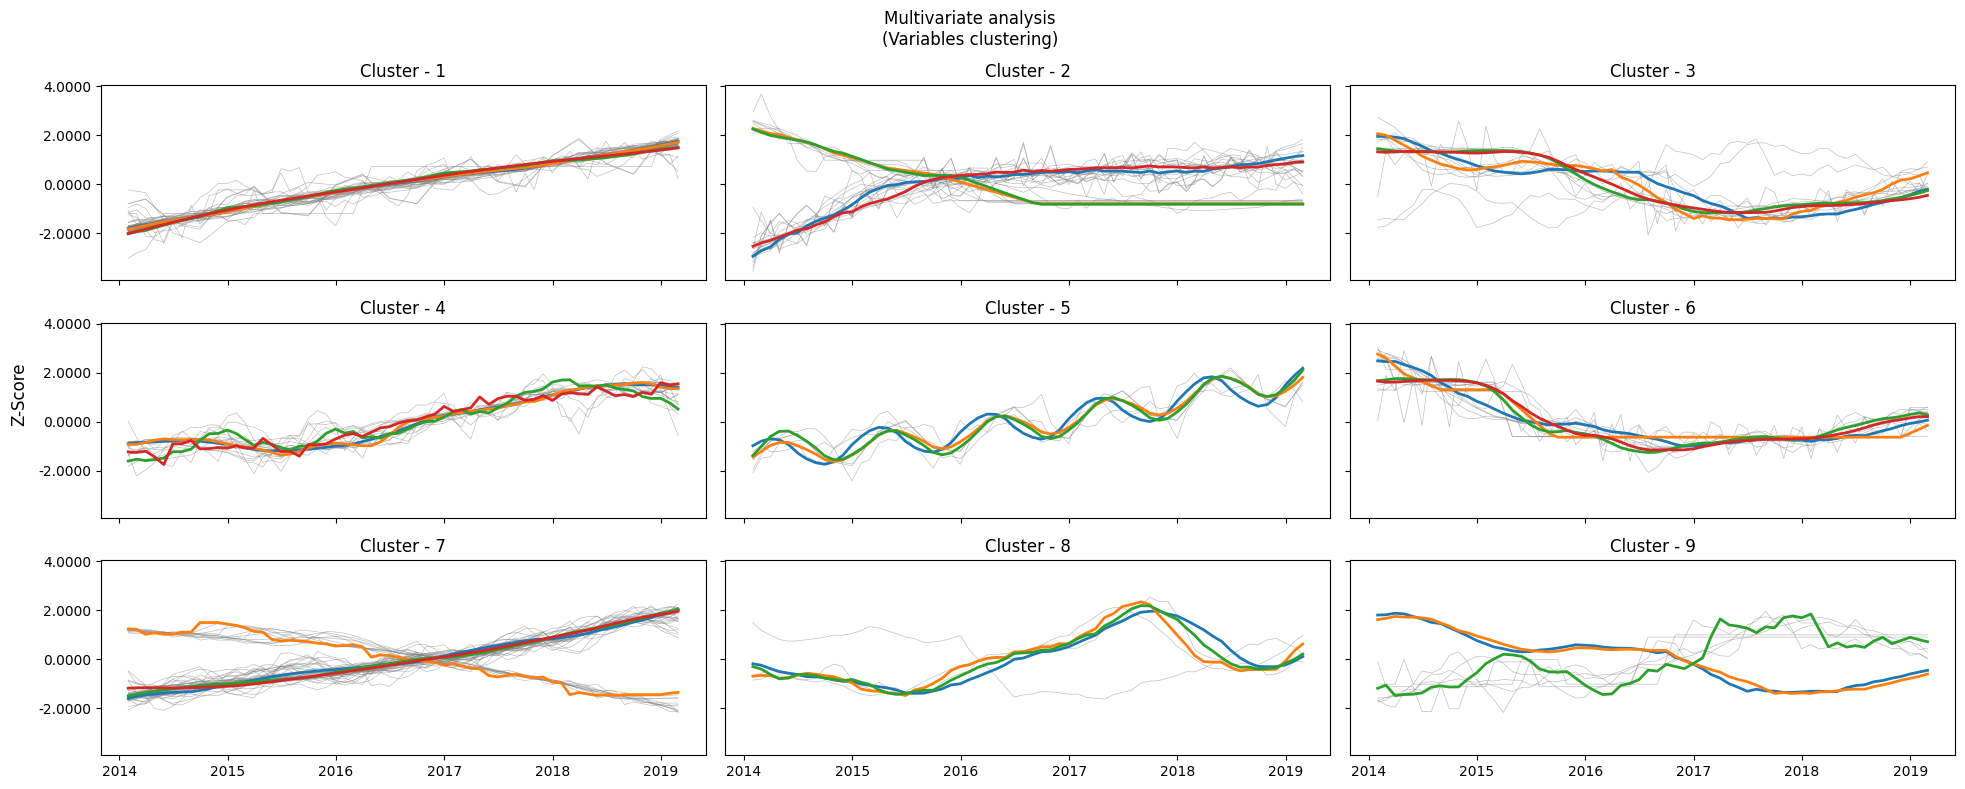

In [9]:
# Multivariate analysis
"""
Selection criteria:
    1. Top 2 lowest R-Square ratio per cluster.
    2. Top 2 highest R-Square per cluster.

"""
multivariate_result, fig = multivariate_selection(
    X = X_train,
    group = X_Sign,
    mev_col = MEV_COL,
    group_col = GROUP_COL,
    univariate_result = univariate_result,
    n_select = 2,
    outplot = True
)

In [10]:
# All possible combinations
"""
Combinations criteria:
    1. 1 combination must not contain variables from same cluster and
    2. 1 combination must not contain variables from same MEV(s) group.
"""
all_possible_combinatios = []
N = 3 #Cap maximum as 3 MEV(s) per model combinations

for n in range(1, N + 1):
    all_possible_combinatios.extend(get_combinations(multivariate_result, n))

print(f"\nTotol combination for regression model: {len(all_possible_combinatios)}")

=== Processing ===
[Possible combinations of 1 variable(s)]
    Number of combinations: 33
=== Processing ===
[Possible combinations of 2 variable(s)]
    Number of combinations: 468
=== Processing ===
[Possible combinations of 3 variable(s)]
    Number of combinations: 3731

Totol combination for regression model: 4232


In [11]:
# Pre-set threshold
pre_set_threshold = {
    "p_value": 0.05,
    "vif": 5,
    "r2": 0.5,
    "adj_r2": 0.5,
    "normality": 0.05,
    "heteroscedasticity": 0.05,
    "autocorrelation": (1, 3),
    "stationary": 0.1,
    "exceed_rate": 0.25,
    "breach_rate": 0.25
}

# FWL Model development in parallel run
results = Parallel(n_jobs = -1)(
    delayed(run_fwl_model)(
        i, combination,
        X_train, y_train, X_Sign,
        model_method = MODEL_METHOD,
        config_threhold = pre_set_threshold,
        std_params = std_params
    )
    for i, combination in enumerate(all_possible_combinatios)
)

# Filter None out
fwl_results = [(k, m, s) for k, m, s in results if k is not None]

# Unpack results
model_names, models, summary_fwl = zip(*fwl_results)

In [12]:
# Summary table
summary_fwl = pd.concat(summary_fwl)

# Show table
summary_fwl.head(5)

,model_name,model_member,variable,coefficient,ols_p_value,hac_p_value,vif,r2,adj_r2,normality,heteroscedasticity,autocorrelation,stationary,exceed_rate,breach_rate,sign
0,MODEL_1,1,const,-2.786,0.000,0.000,0.000,0.627,0.621,0.170,0.000,0.134,0.016,0.016,0.022,0.000
1,MODEL_1,2,FRES_C_LAG12M,-4.249,0.000,0.000,1.000,0.627,0.621,0.170,0.000,0.134,0.016,0.016,0.022,-1.000
0,MODEL_13,1,const,-5.331,0.000,0.000,0.000,0.783,0.780,0.082,0.003,0.069,0.079,0.000,0.028,0.000
1,MODEL_13,2,PIR_MA6M,1.442,0.000,0.000,1.000,0.783,0.780,0.082,0.003,0.069,0.079,0.000,0.028,0.000
0,MODEL_16,1,const,3.233,0.000,0.002,0.000,0.646,0.640,0.347,0.921,0.095,0.076,0.048,0.052,0.000


In [13]:
# Model selection
"""
Selection criteria:
    1. p-value < 0.05 and
    2. VIF < 5 and
    3. R-Square >= 50% and
    4. Adjusted R-Square >= 50% and
    5. Normality > 0.05 and
    6. Heteroscedasticity > 0.05 and
    7. Autocorrelation between 1 and 3 and
    8. Stationary <= 0.1 and
    9. Exceed rate <= 25% and
    10. Breach rate <= 25% and
    11. Allowed either sign and coefficient followed expected sign

For failed with Heteroscedasticity and Autocorrelation, if the p-value of HAC is significant,
the model is still applicable to select.
"""
# OLS Mask
ols_mask = (
    mask_selection(summary_fwl, "ols_p_value", pre_set_threshold) &
    (summary_fwl["heteroscedasticity"] > pre_set_threshold["heteroscedasticity"]) &
    (
        summary_fwl["autocorrelation"].between(
            pre_set_threshold["autocorrelation"][0], pre_set_threshold["autocorrelation"][1],
            inclusive = "both"
        )
    )
)

# HAC Mask
hac_mask = mask_selection(summary_fwl, "hac_p_value", pre_set_threshold)

In [14]:
# Select passed models
passed_ols = select_models(summary_fwl, ols_mask)
passed_hac = select_models(summary_fwl, hac_mask)

# Combine and deduplicate
candidate_models = (
    pd.concat([passed_ols, passed_hac], ignore_index = True)
    .drop_duplicates()
    .sort_values(["adj_r2", "model_name"], ascending = [False, False])
)

# Show table
candidate_models.tail(5)

,model_name,model_member,variable,coefficient,ols_p_value,hac_p_value,vif,r2,adj_r2,normality,heteroscedasticity,autocorrelation,stationary,exceed_rate,breach_rate,sign
1138,MODEL_16,2,GDP_MA6M,-0.000,0.000,0.000,1.000,0.646,0.640,0.347,0.921,0.095,0.076,0.048,0.052,-1.000
1139,MODEL_1,1,const,-2.786,0.000,0.000,0.000,0.627,0.621,0.170,0.000,0.134,0.016,0.016,0.022,0.000
1140,MODEL_1,2,FRES_C_LAG12M,-4.249,0.000,0.000,1.000,0.627,0.621,0.170,0.000,0.134,0.016,0.016,0.022,-1.000
1141,MODEL_17,1,const,2.368,0.000,0.016,0.000,0.559,0.551,0.464,0.906,0.104,0.053,0.081,0.043,0.000
1142,MODEL_17,2,GDP_MA3M,-0.000,0.000,0.000,1.000,0.559,0.551,0.464,0.906,0.104,0.053,0.081,0.043,-1.000


In [15]:
# Model object
all_models_object = dict(zip(model_names, models))

# Candidate model object
candidate_models_object = {
    k: v for k, v in all_models_object.items()
    if k in candidate_models["model_name"].unique()
}

# Export
with open('../model/fwl_model.pkl', 'wb') as f:
    pickle.dump(candidate_models_object, f)

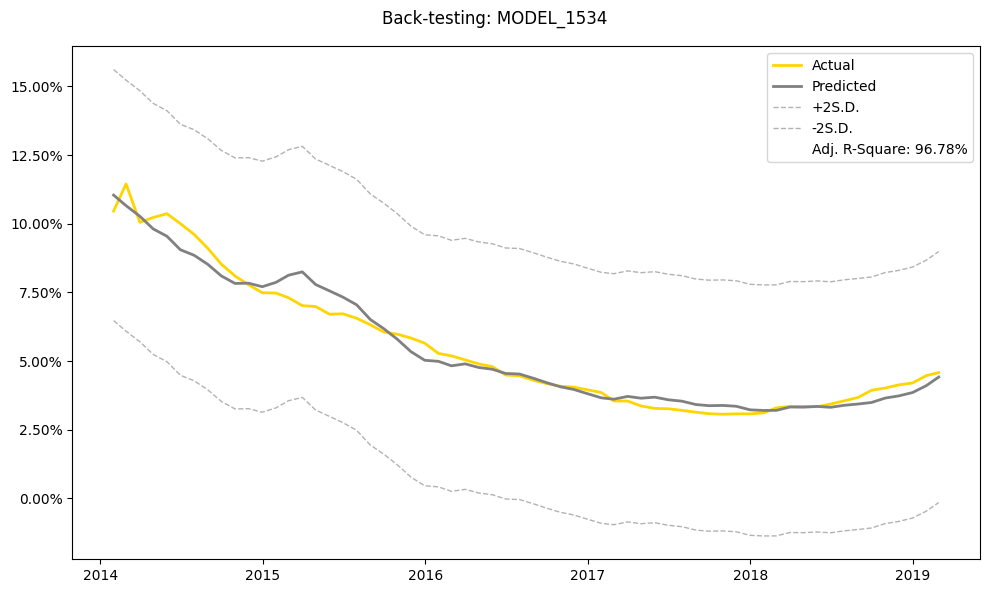

In [ ]:
# Plot back-testing
MODEL_NAME = np.random.choice(candidate_models["model_name"].unique())
plot_backtest(
    y_train,
    model = candidate_models_object,
    model_name = MODEL_NAME,
    model_method = MODEL_METHOD
)